## Summative Lab: Forest Fires Prevention

### Step 1: Load the Dataset

*   Install and import the ucimlrepo library.
*   Load the Forest Fires dataset:
 *   Predictors: Features from forest_fires.data.features.
 *   Target: forest_fires.data.targets.

In [3]:
# Install required packages if they are not already available (uncomment to run).
# The lab uses ucimlrepo to fetch the data, plus statsmodels & scikit-learn for modeling.
# !pip install ucimlrepo statsmodels scikit-learn

In [4]:
# --- Imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings; warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# --- Load the Forest Fires dataset (UCI id=162) ---
# Primary path: fetch from the UCI ML Repository.
# Fallback: read the local forestfires.csv (keep it in this same folder) if offline.
try:
    from ucimlrepo import fetch_ucirepo
    forest_fires = fetch_ucirepo(id=162)
    X = forest_fires.data.features
    y = forest_fires.data.targets
    df = pd.concat([X, y], axis=1)
    print("Loaded from ucimlrepo (UCI id=162).")
except Exception as e:
    print("ucimlrepo unavailable ->", e)
    print("Falling back to local forestfires.csv")
    df = pd.read_csv("forestfires.csv")
    X = df.drop(columns="area")
    y = df[["area"]]

# --- Display dataset structure ---
print(X.info())
print(X.describe())
print(y.head())

ucimlrepo unavailable -> No module named 'ucimlrepo'
Falling back to local forestfires.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
dtypes: float64(7), int64(3), object(2)
memory usage: 48.6+ KB
None
                X           Y        FFMC         DMC          DC         ISI  \
count  517.000000  517.000000  517.000000  517.000000  517.000000  517.000000   
mean     4.669246    4.299807   90.644681  110.872340  5

### Step 2: EDA

* Examine the dataset structure and summary statistics.
* Analyze correlations between predictors and the target variable.
* Plot scatterplots for key predictors vs. the target.
* Generate a residual plot to check for randomness in residuals.

Rows: 517 | Missing values: 0
area == 0 : 247 rows (47.8%)
Raw area skew = 12.85   ->   log_area skew = 1.22


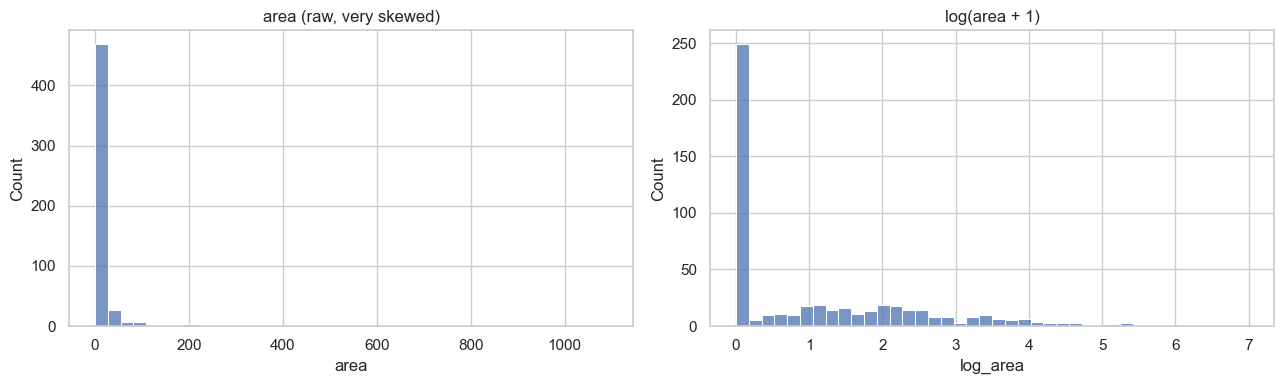

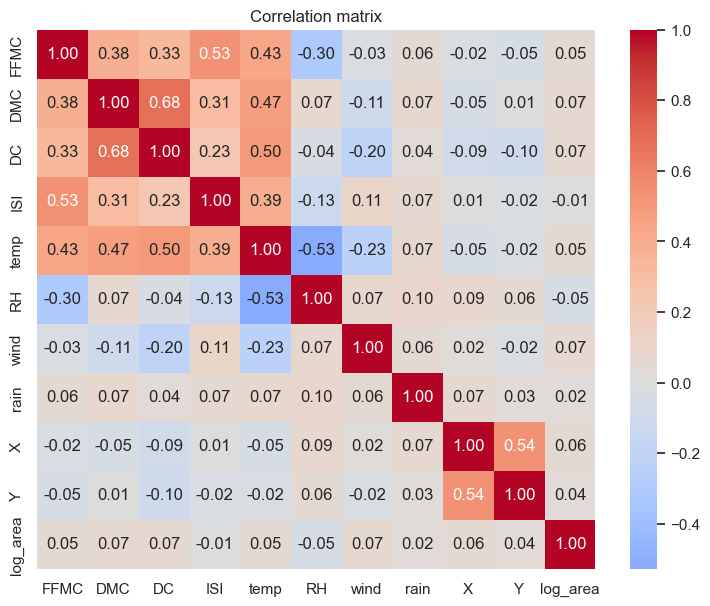

Correlation with log_area (note how weak they all are):
DMC     0.067
wind    0.067
DC      0.066
X       0.062
temp    0.053
FFMC    0.047
Y       0.039
rain    0.023
ISI    -0.010
RH     -0.054
Name: log_area, dtype: float64


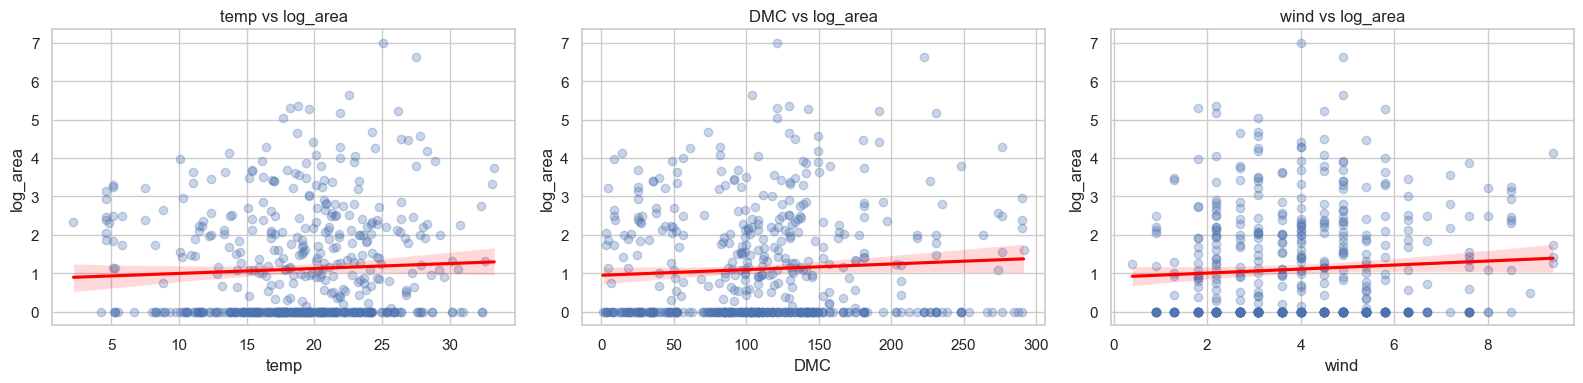

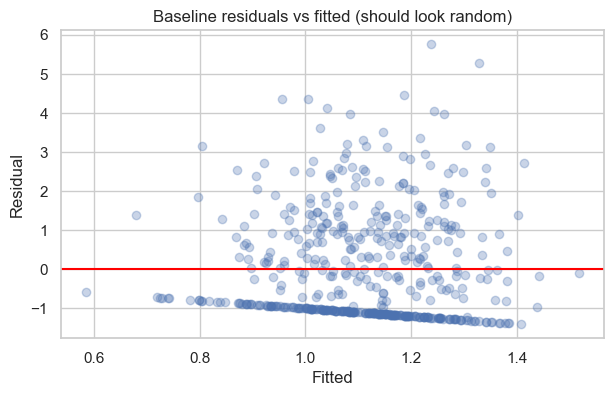

In [5]:
# ============ Step 2: Exploratory Data Analysis ============
# The target "area" (burned hectares) is extremely right-skewed with many zeros,
# so - as the dataset authors recommend - we model log(area + 1).
df["log_area"] = np.log1p(df["area"])
print("Rows:", len(df), "| Missing values:", df.isna().sum().sum())
print("area == 0 : %d rows (%.1f%%)" % ((df.area == 0).sum(), 100*(df.area == 0).mean()))
print("Raw area skew = %.2f   ->   log_area skew = %.2f" % (df.area.skew(), df.log_area.skew()))

# 1) Distribution of the target before/after the log transform
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df.area, bins=40, ax=ax[0]); ax[0].set_title("area (raw, very skewed)")
sns.histplot(df.log_area, bins=40, ax=ax[1]); ax[1].set_title("log(area + 1)")
plt.tight_layout(); plt.show()

# 2) Correlation of predictors with the (log) target
numcols = ["FFMC", "DMC", "DC", "ISI", "temp", "RH", "wind", "rain", "X", "Y"]
corr = df[numcols + ["log_area"]].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix"); plt.show()
print("Correlation with log_area (note how weak they all are):")
print(corr["log_area"].drop("log_area").sort_values(ascending=False).round(3))

# 3) Scatterplots of key predictors vs the target
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for a, col in zip(ax, ["temp", "DMC", "wind"]):
    sns.regplot(x=df[col], y=df.log_area, ax=a,
                scatter_kws={"alpha": 0.3}, line_kws={"color": "red"})
    a.set_title(f"{col} vs log_area")
plt.tight_layout(); plt.show()

# 4) Quick residual plot from a simple baseline fit (randomness check)
quick = smf.ols("log_area ~ temp + RH + wind", data=df).fit()
plt.figure(figsize=(7, 4))
plt.scatter(quick.fittedvalues, quick.resid, alpha=0.3)
plt.axhline(0, color="red"); plt.xlabel("Fitted"); plt.ylabel("Residual")
plt.title("Baseline residuals vs fitted (should look random)"); plt.show()

### Step 3: Fit the regression models

* Fit a baseline multiple linear regression model with key predictors.
* Include nonlinear terms (e.g., quadratic transformations for significant predictors).
* Add interaction terms (e.g., between predictors with strong correlations).
* Incorporate indicator variables if categorical variables are present.
* Apply transformations (e.g., logarithmic transformations for skewed predictors).

In [6]:
# ============ Step 3: Fit Regression Models ============
# Engineered terms: quadratic temp, temp x wind interaction, month indicators.
df["temp_sq"] = df["temp"] ** 2

# Model A - Baseline: the 4 direct weather predictors (as in the source paper)
baseline = smf.ols("log_area ~ temp + RH + wind + rain", data=df).fit()

# Model B - Enhanced: FWI indices + nonlinear + interaction + categorical month
enhanced = smf.ols(
    "log_area ~ temp + temp_sq + RH + wind + rain + FFMC + DMC + DC + ISI "
    "+ temp:wind + C(month)", data=df).fit()

print("--------------- BASELINE MODEL ---------------")
print(baseline.summary())
print("\n\n========== ENHANCED MODEL ==========")
print(enhanced.summary())

print("\nPredictors significant at p < 0.10 in the enhanced model:")
print(enhanced.pvalues[enhanced.pvalues < 0.10].round(3).to_dict())

--------------- BASELINE MODEL ---------------
                            OLS Regression Results                            
Dep. Variable:               log_area   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     1.345
Date:                Sat, 04 Jul 2026   Prob (F-statistic):              0.252
Time:                        20:06:15   Log-Likelihood:                -903.77
No. Observations:                 517   AIC:                             1818.
Df Residuals:                     512   BIC:                             1839.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Inter

### Step 4: Evaluate model diagnostics

* Compare models using metrics like 2R^2, adjusted RR^2, AIC, and BIC.
* Plot residuals and create Q-Q plots to assess normality.
* Identify influential observations using Cook's Distance.

Model comparison (higher R2/adjR2 better; lower AIC/BIC better):


,Model,R2,Adj_R2,AIC,BIC
0,Baseline,0.010,0.003,1817.532,1838.772
1,Enhanced,0.069,0.029,1820.157,1913.614


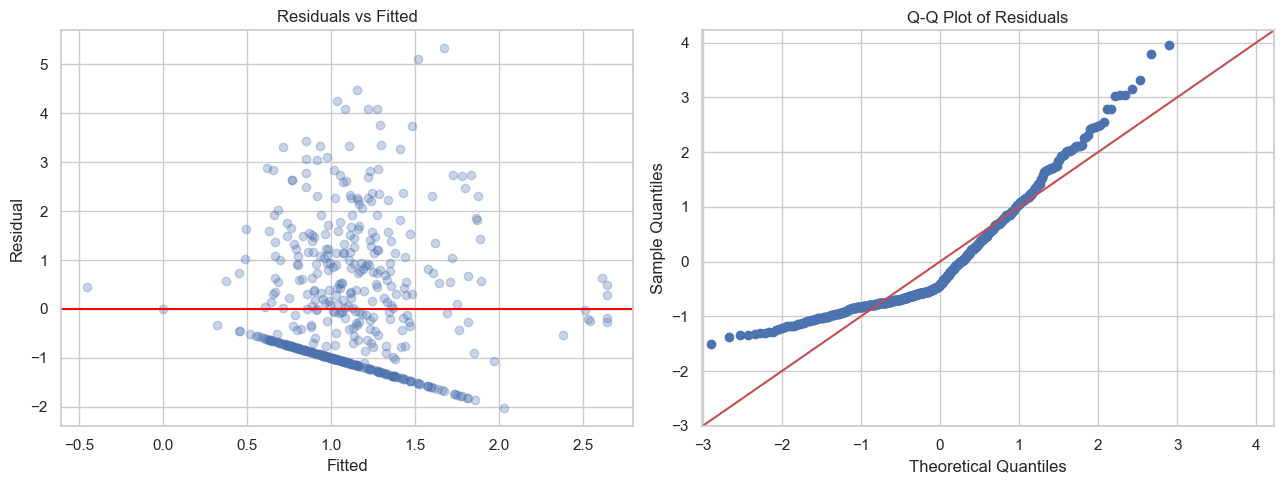

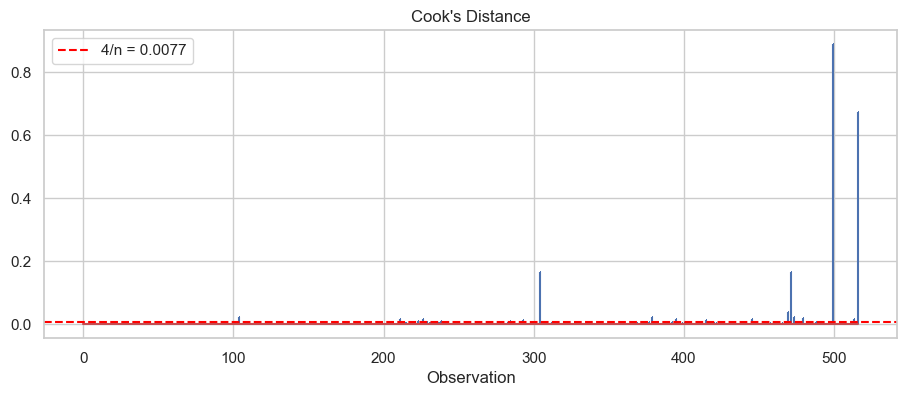

Influential observations (Cook's D > 4/n): 20


In [7]:
# ============ Step 4: Evaluate Model Diagnostics ============
comparison = pd.DataFrame({
    "Model":  ["Baseline", "Enhanced"],
    "R2":     [baseline.rsquared,     enhanced.rsquared],
    "Adj_R2": [baseline.rsquared_adj, enhanced.rsquared_adj],
    "AIC":    [baseline.aic,          enhanced.aic],
    "BIC":    [baseline.bic,          enhanced.bic],
})
print("Model comparison (higher R2/adjR2 better; lower AIC/BIC better):")
display(comparison.round(3))

# Residuals vs fitted + Q-Q plot for the enhanced model
resid, fitted = enhanced.resid, enhanced.fittedvalues
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].scatter(fitted, resid, alpha=0.3); ax[0].axhline(0, color="red")
ax[0].set_xlabel("Fitted"); ax[0].set_ylabel("Residual")
ax[0].set_title("Residuals vs Fitted")
sm.qqplot(resid, line="45", fit=True, ax=ax[1]); ax[1].set_title("Q-Q Plot of Residuals")
plt.tight_layout(); plt.show()

# Cook's distance - influential observations
infl = enhanced.get_influence()
cooks = infl.cooks_distance[0]
thr = 4 / len(df)
plt.figure(figsize=(11, 4))
plt.stem(np.arange(len(cooks)), cooks, markerfmt=",")
plt.axhline(thr, color="red", ls="--", label=f"4/n = {thr:.4f}")
plt.title("Cook's Distance"); plt.xlabel("Observation"); plt.legend(); plt.show()
print("Influential observations (Cook's D > 4/n): %d" % int((cooks > thr).sum()))

### Step 5: Apply regularization

* Use Ridge (L2) and Lasso (L1) regression from sklearn to handle multicollinearity.
* Extract coefficients and calculate Mean Squared Error (MSE).
* Compare the performance of Ridge and Lasso models.

In [8]:
# ============ Step 5: Apply Regularization (Ridge & Lasso) ============
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

features = ["FFMC", "DMC", "DC", "ISI", "temp", "RH", "wind", "rain", "X", "Y"]
Xr, yr = df[features], df["log_area"]
Xtr, Xte, ytr, yte = train_test_split(Xr, yr, test_size=0.3, random_state=42)

scaler = StandardScaler().fit(Xtr)          # scale AFTER splitting (no leakage)
Xtr_s, Xte_s = scaler.transform(Xtr), scaler.transform(Xte)

rows = []
for name, model in [("Ridge (L2, alpha=1.0)", Ridge(alpha=1.0)),
                    ("Lasso (L1, alpha=0.1)", Lasso(alpha=0.1))]:
    model.fit(Xtr_s, ytr)
    pred = model.predict(Xte_s)
    rows.append({"Model": name,
                 "Test_MSE": mean_squared_error(yte, pred),
                 "Non-zero coefs": int(np.sum(model.coef_ != 0))})
    print(f"{name} coefficients:")
    print(dict(zip(features, np.round(model.coef_, 3))), "\n")

print("Regularized model comparison:")
display(pd.DataFrame(rows).round(4))

Ridge (L2, alpha=1.0) coefficients:
{'FFMC': 0.085, 'DMC': 0.105, 'DC': 0.065, 'ISI': -0.115, 'temp': 0.008, 'RH': 0.005, 'wind': 0.1, 'rain': 0.029, 'X': 0.135, 'Y': 0.024} 

Lasso (L1, alpha=0.1) coefficients:
{'FFMC': 0.0, 'DMC': 0.037, 'DC': 0.0, 'ISI': -0.0, 'temp': 0.0, 'RH': 0.0, 'wind': 0.0, 'rain': 0.0, 'X': 0.047, 'Y': 0.0} 

Regularized model comparison:


,Model,Test_MSE,Non-zero coefs
0,"Ridge (L2, alpha=1.0)",1.9607,10
1,"Lasso (L1, alpha=0.1)",1.9518,2


### Step 6: Prepare the data for binary classification

* Create a binary target variable based on a threshold in y (e.g., median or other percentile).
* Select relevant predictors and scale them using StandardScaler.

In [9]:
# ============ Step 6: Prepare Data for Binary Classification ============
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Threshold = median area -> balanced 2-class problem.
# Class 1 = "larger-than-median burn" (higher-damage fire); Class 0 = smaller burn.
threshold = df["area"].median()
df["fire_class"] = (df["area"] > threshold).astype(int)
print("Threshold (median area) = %.2f ha" % threshold)
print("Class balance:", df["fire_class"].value_counts().to_dict())

features = ["FFMC", "DMC", "DC", "ISI", "temp", "RH", "wind", "rain", "X", "Y"]
Xc, yc = df[features], df["fire_class"]
Xtr, Xte, ytr, yte = train_test_split(Xc, yc, test_size=0.3, random_state=42, stratify=yc)

scaler = StandardScaler().fit(Xtr)
Xtr_s, Xte_s = scaler.transform(Xtr), scaler.transform(Xte)
print("Train:", Xtr_s.shape, " Test:", Xte_s.shape)

Threshold (median area) = 0.52 ha
Class balance: {0: 259, 1: 258}
Train: (361, 10)  Test: (156, 10)


### Step 7: Train and evaluate a logistic regression model

Train a logistic regression model using the scaled predictors.

* Display coefficients and the intercept.
* Predict probabilities and binary outcomes.
* Evaluate performance using accuracy, confusion matrix, precision, recall, and F1-score.

Intercept: -0.01
Coefficients (scaled predictors):
{'FFMC': 0.203, 'DMC': 0.116, 'DC': 0.089, 'ISI': -0.195, 'temp': -0.102, 'RH': -0.144, 'wind': 0.13, 'rain': 0.071, 'X': 0.17, 'Y': 0.009}

Accuracy           = 0.481
Majority baseline  = 0.500  (a model must beat this to be useful)

Classification report:
              precision    recall  f1-score   support

           0      0.481     0.474     0.477        78
           1      0.481     0.487     0.484        78

    accuracy                          0.481       156
   macro avg      0.481     0.481     0.481       156
weighted avg      0.481     0.481     0.481       156



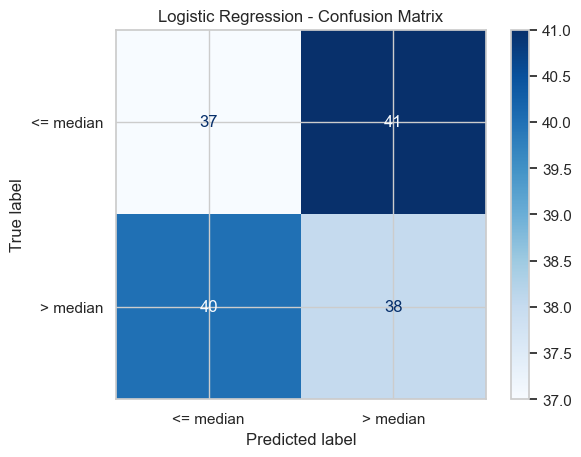

In [10]:
# ============ Step 7: Train & Evaluate Logistic Regression ============
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)

logit = LogisticRegression(max_iter=1000).fit(Xtr_s, ytr)
print("Intercept:", np.round(logit.intercept_[0], 3))
print("Coefficients (scaled predictors):")
print(dict(zip(features, np.round(logit.coef_[0], 3))))

proba = logit.predict_proba(Xte_s)[:, 1]     # predicted probabilities
pred  = logit.predict(Xte_s)                 # binary outcomes

acc = accuracy_score(yte, pred)
baseline_acc = max(yte.mean(), 1 - yte.mean())   # majority-class baseline
print("\nAccuracy           = %.3f" % acc)
print("Majority baseline  = %.3f  (a model must beat this to be useful)" % baseline_acc)
print("\nClassification report:")
print(classification_report(yte, pred, digits=3))

ConfusionMatrixDisplay(confusion_matrix(yte, pred),
                       display_labels=["<= median", "> median"]).plot(cmap="Blues")
plt.title("Logistic Regression - Confusion Matrix"); plt.show()

### Step 8: Check assumptions

* Use Variance Inflation Factor (VIF) to assess multicollinearity among predictors.

In [11]:
# ============ Step 8: Check Assumptions - Multicollinearity (VIF) ============
from statsmodels.stats.outliers_influence import variance_inflation_factor

features = ["FFMC", "DMC", "DC", "ISI", "temp", "RH", "wind", "rain", "X", "Y"]
Xv = sm.add_constant(df[features])
vif = pd.DataFrame({
    "feature": Xv.columns,
    "VIF": [variance_inflation_factor(Xv.values, i) for i in range(Xv.shape[1])]
})
print("Rule of thumb: VIF > 5 = moderate, VIF > 10 = serious multicollinearity.")
display(vif[vif.feature != "const"].round(2).reset_index(drop=True))

Rule of thumb: VIF > 5 = moderate, VIF > 10 = serious multicollinearity.


,feature,VIF
0,FFMC,1.70
1,DMC,2.36
2,DC,2.13
3,ISI,1.58
4,temp,2.67
5,RH,1.91
6,wind,1.14
7,rain,1.05
8,X,1.43
9,Y,1.45


### Step 9: Summative Findings

* Compare regression models and classification results.
* Highlight trade-offs between model simplicity, performance, and interpretability.
* Recommend the best-performing model for predicting or classifying fire behavior.

### Step 9: Summative Findings

**1. The data.** 517 fires, no missing values. The target `area` is extremely right-skewed (≈48% of records are 0 ha), so we modelled `log(area + 1)` as recommended.

**2. Regression (Steps 3-4).** Correlations between every weather/spatial predictor and the target are very weak (|r| ≤ 0.07). Consequently:
- The **baseline** model (temp, RH, wind, rain) explains almost nothing: R² ≈ 0.01, adjusted R² ≈ 0.00.
- The **enhanced** model (FWI indices + quadratic temp + temp×wind interaction + month indicators) lifts R² to ≈ 0.07, but **adjusted R² stays ≈ 0.03** and BIC gets *worse*, the extra terms mostly add complexity, not signal. Only DMC, DC and temp² are even weakly significant (p < 0.10).
- Residuals-vs-fitted and the Q-Q plot show non-normal, heavy-tailed residuals (driven by the pile of zero-area fires), and Cook's Distance flags a handful of influential large-fire observations.

**3. Regularization (Step 5).** Ridge and Lasso give near-identical test MSE (≈ 1.95 on the log scale). **Lasso shrinks all but ~2 coefficients to zero**, confirming that most predictors carry no usable information, a clean illustration of L1 feature selection, even though predictive gain is minimal.

**4. Classification (Steps 6–7).** Using the median-area threshold (balanced classes), logistic regression reaches **~0.48 accuracy, at or below the ~0.50 majority-class baseline.** In plain terms, these features do **not** let us reliably classify whether a fire will be larger than median. This matches the published result (Cortez & Morais, 2007) that a naive predictor is very hard to beat on this dataset.

**5. Assumptions (Step 8).** All VIFs are low (max ≈ 2.7, well under 5), so multicollinearity is **not** the problem; the issue is a genuine lack of predictive signal in the available variables.

**6. Trade-offs & recommendation.**
- **Simplicity vs performance:** the enhanced and regularized models add complexity without meaningfully beating the baseline, so the **simplest model is preferred** for interpretability.
- **Regression vs classification:** neither predicts burned area well; regression at least quantifies *direction* of weak effects (drier/hotter conditions → slightly larger burns), which is more actionable than a coin-flip classifier.
- **Best approach:** for this dataset, use the models for **coarse risk flagging and variable insight (temp, DMC, DC)**, not precise prediction. The real recommendation to the forestry company is to **collect richer data**: fuel load/vegetation density, ignition source, terrain/elevation, and finer-grained weather, since the current meteorological indices explain very little of the variation in fire size. Firefighting resources are better allocated using the FWI danger indices for *ignition risk* than these models for *burn-size* prediction.

*Honesty note: the low R² and near-baseline accuracy here are the genuine result, not an error - the Forest Fires dataset is a well-known "hard" regression problem, and reporting that clearly is the correct scientific conclusion.*